In [ ]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Step 2: Upload Sentiment Dataset

from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

Saving final_sentiment_dataset.csv to final_sentiment_dataset.csv
File uploaded successfully!


In [ ]:
# Load the uploaded CSV file

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
File: final_sentiment_dataset.csv
Shape: (5000, 4)

Columns:
['id', 'text', 'sentiment', 'domain']

First 5 rows:


,id,text,sentiment,domain
0,1,आज मागवलेल्या पुस्तकाची छपाई आणि बांधणी दोन्ही...,Positive,ऑनलाइन व्यापार
1,2,जेवणात मिठाचे प्रमाण इतके जास्त होते की चवच बि...,Negative,उपाहारगृह
2,3,या चित्रपटाचा दुसरा भाग पुढील महिन्यात प्रदर्श...,Neutral,चित्रपट
3,4,उपचारानंतर माझी प्रकृती अपेक्षेपेक्षा लवकर सुध...,Positive,आरोग्यसेवा
4,5,प्रयोगशाळेतील अनेक उपकरणे आज बंद असल्यामुळे सर...,Negative,शिक्षण


In [ ]:
# Step 3: Check Dataset Information

print("===== DATASET INFORMATION =====")

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nDomain Distribution:")
print(df["domain"].value_counts())

===== DATASET INFORMATION =====

Shape:
(5000, 4)

Data Types:
id            int64
text         object
sentiment    object
domain       object
dtype: object

Missing Values:
id           0
text         0
sentiment    0
domain       0
dtype: int64

Duplicate Rows:
0

Sentiment Distribution:
sentiment
Positive    1672
Negative    1668
Neutral     1660
Name: count, dtype: int64

Domain Distribution:
domain
स्वरूप              751
ऑनलाइन व्यापार      552
तंत्रज्ञान          324
अन्न                310
मनोरंजन             281
शिक्षण              280
प्रवास              163
क्रीडा              159
ग्राहक सेवा         144
सरकारी सेवा         142
चित्रपट             133
आरोग्यसेवा          130
बँकिंग              127
उपाहारगृह           126
शेती                125
वाहतूक              124
मोबाईल अॅप्स        120
सामाजिक माध्यमे     116
अन्न वितरण           94
सार्वजनिक वाहतूक     86
ऑनलाइन खरेदी         85
वेशभूषा              85
नोकरी                85
कार्यालय             77
संभाषण           

In [ ]:
# Step 4: Encode Sentiment Labels

label_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["label"] = df["sentiment"].map(label_mapping)

print("Label mapping:", label_mapping)

print("\nFirst 10 encoded labels:")
display(df[["sentiment", "label"]].head(10))

print("\nEncoded label distribution:")
print(df["label"].value_counts().sort_index())

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}

First 10 encoded labels:


,sentiment,label
0,Positive,2
1,Negative,0
2,Neutral,1
3,Positive,2
4,Negative,0
5,Neutral,1
6,Positive,2
7,Negative,0
8,Neutral,1
9,Positive,2



Encoded label distribution:
label
0    1668
1    1660
2    1672
Name: count, dtype: int64


In [ ]:
# Step 5: Create Train, Validation, and Test Splits

# First split: 80% temporary, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# Second split: 90% train, 10% validation of the remaining 80%
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.10,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Dataset split completed successfully!")

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTesting distribution:")
print(test_df["label"].value_counts().sort_index())

Dataset split completed successfully!

Training samples: 3600
Validation samples: 400
Testing samples: 1000

Training distribution:
label
0    1201
1    1195
2    1204
Name: count, dtype: int64

Validation distribution:
label
0    133
1    133
2    134
Name: count, dtype: int64

Testing distribution:
label
0    334
1    332
2    334
Name: count, dtype: int64


In [ ]:
# Step 6: Convert Pandas DataFrames to Hugging Face Datasets

!pip -q install datasets

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print("Hugging Face datasets created successfully!")

print("\nTrain dataset:")
print(train_dataset)

print("\nValidation dataset:")
print(val_dataset)

print("\nTest dataset:")
print(test_dataset)

Hugging Face datasets created successfully!

Train dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 3600
})

Validation dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 400
})

Test dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


In [ ]:
# Step 7: Create Common Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Get predicted class
    predictions = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics function created successfully!")

Evaluation metrics function created successfully!


In [ ]:
# Step 8: Load BERT Tokenizer and Model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

BERT_MODEL_NAME = "bert-base-uncased"
NUM_LABELS = len(label_mapping)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("BERT loaded successfully!")
print("Model:", BERT_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT loaded successfully!
Model: bert-base-uncased
Number of labels: 3


In [ ]:
# Step 9: Tokenize BERT datasets

def bert_tokenize_function(examples):
    return bert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

bert_train_tokenized = train_dataset.map(
    bert_tokenize_function,
    batched=True
)

bert_val_tokenized = val_dataset.map(
    bert_tokenize_function,
    batched=True
)

bert_test_tokenized = test_dataset.map(
    bert_tokenize_function,
    batched=True
)

print("BERT tokenization completed!")

print("\nTrain features:")
print(bert_train_tokenized.features)

print("\nValidation features:")
print(bert_val_tokenized.features)

print("\nTest features:")
print(bert_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

BERT tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 10: Prepare BERT Datasets for Training

bert_train_tokenized = bert_train_tokenized.remove_columns(["text"])
bert_val_tokenized = bert_val_tokenized.remove_columns(["text"])
bert_test_tokenized = bert_test_tokenized.remove_columns(["text"])

bert_train_tokenized.set_format("torch")
bert_val_tokenized.set_format("torch")
bert_test_tokenized.set_format("torch")

print("BERT datasets prepared successfully!")

print("\nTrain columns:", bert_train_tokenized.column_names)
print("Validation columns:", bert_val_tokenized.column_names)
print("Test columns:", bert_test_tokenized.column_names)

BERT datasets prepared successfully!

Train columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# Step 11: BERT Training Configuration

from transformers import TrainingArguments

bert_training_args = TrainingArguments(
    output_dir="./bert_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("BERT training configuration created successfully!")
print("Epochs:", bert_training_args.num_train_epochs)
print("Train batch size:", bert_training_args.per_device_train_batch_size)
print("Learning rate:", bert_training_args.learning_rate)

BERT training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 13A: Disable torchvision to avoid the VideoReader compatibility issue

import sys

# Remove torchvision from the current Python session
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

# Tell Hugging Face Transformers that torchvision is unavailable
import os
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

print("Torchvision disabled for this training session!")

Torchvision disabled for this training session!


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU available: True
GPU: Tesla T4


In [ ]:
# Step 13B: Train BERT

print("Starting BERT training...\n")

bert_train_result = bert_trainer.train()

print("\nBERT training completed successfully!")

Starting BERT training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.564678,0.304245,0.900000,0.904688,0.900000,0.898825
2,0.234030,0.197565,0.957500,0.957642,0.957500,0.957508
3,0.140015,0.211024,0.957500,0.957695,0.957500,0.957535


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


BERT training completed successfully!


In [ ]:
# Step 14: Evaluate BERT on Test Dataset

print("Evaluating BERT on test dataset...\n")

bert_test_results = bert_trainer.evaluate(
    bert_test_tokenized
)

print("===== BERT Test Results =====")

for key, value in bert_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating BERT on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.140015,0.172243,3,0.958000,0.958225,0.958000,0.957807


===== BERT Test Results =====
eval_loss: 0.1722
eval_accuracy: 0.9580
eval_precision: 0.9582
eval_recall: 0.9580
eval_f1: 0.9578


In [ ]:
# Step 15: BERT Classification Report and Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix

print("Generating BERT predictions...\n")

bert_predictions = bert_trainer.predict(
    bert_test_tokenized
)

bert_y_pred = np.argmax(
    bert_predictions.predictions,
    axis=1
)

bert_y_true = bert_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== BERT Classification Report =====")

print(
    classification_report(
        bert_y_true,
        bert_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== BERT Confusion Matrix =====")

bert_cm = confusion_matrix(
    bert_y_true,
    bert_y_pred
)

print(bert_cm)

Generating BERT predictions...



===== BERT Classification Report =====
              precision    recall  f1-score   support

    Negative     0.9522    0.9551    0.9537       334
     Neutral     0.9538    0.9940    0.9735       332
    Positive     0.9687    0.9251    0.9464       334

    accuracy                         0.9580      1000
   macro avg     0.9582    0.9581    0.9578      1000
weighted avg     0.9582    0.9580    0.9578      1000

===== BERT Confusion Matrix =====
[[319   5  10]
 [  2 330   0]
 [ 14  11 309]]


In [ ]:
# Step 16: Save BERT Model

BERT_SAVE_PATH = "./bert_sentiment_model"

bert_trainer.save_model(BERT_SAVE_PATH)
bert_tokenizer.save_pretrained(BERT_SAVE_PATH)

print("BERT model saved successfully!")
print("Location:", BERT_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved successfully!
Location: ./bert_sentiment_model


In [ ]:
# Step 16: Create Transformer Results Table and Save BERT

# Save BERT model
BERT_SAVE_PATH = "./bert_sentiment_model"

bert_trainer.save_model(BERT_SAVE_PATH)
bert_tokenizer.save_pretrained(BERT_SAVE_PATH)

print("BERT model saved successfully!")
print("Location:", BERT_SAVE_PATH)


# Create Transformer results table
transformer_results = pd.DataFrame([{
    "Model": "BERT",
    "Accuracy": bert_test_results["eval_accuracy"],
    "Precision": bert_test_results["eval_precision"],
    "Recall": bert_test_results["eval_recall"],
    "F1-Score": bert_test_results["eval_f1"]
}])

print("\n===== Transformer Results =====")
display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved successfully!
Location: ./bert_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578


In [ ]:
# Step 17: Load mBERT Tokenizer and Model

MBERT_MODEL_NAME = "bert-base-multilingual-cased"

mbert_tokenizer = AutoTokenizer.from_pretrained(
    MBERT_MODEL_NAME
)

mbert_model = AutoModelForSequenceClassification.from_pretrained(
    MBERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("mBERT loaded successfully!")
print("Model:", MBERT_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mBERT loaded successfully!
Model: bert-base-multilingual-cased
Number of labels: 3


In [ ]:
# Step 18: Tokenize mBERT Datasets

def mbert_tokenize_function(examples):
    return mbert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

mbert_train_tokenized = train_dataset.map(
    mbert_tokenize_function,
    batched=True
)

mbert_val_tokenized = val_dataset.map(
    mbert_tokenize_function,
    batched=True
)

mbert_test_tokenized = test_dataset.map(
    mbert_tokenize_function,
    batched=True
)

print("mBERT tokenization completed!")

print("\nTrain features:")
print(mbert_train_tokenized.features)

print("\nValidation features:")
print(mbert_val_tokenized.features)

print("\nTest features:")
print(mbert_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

mBERT tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 19: Prepare mBERT Datasets for Training

mbert_train_tokenized = mbert_train_tokenized.remove_columns(["text"])
mbert_val_tokenized = mbert_val_tokenized.remove_columns(["text"])
mbert_test_tokenized = mbert_test_tokenized.remove_columns(["text"])

mbert_train_tokenized.set_format("torch")
mbert_val_tokenized.set_format("torch")
mbert_test_tokenized.set_format("torch")

print("mBERT datasets prepared successfully!")

print("\nTrain columns:", mbert_train_tokenized.column_names)
print("Validation columns:", mbert_val_tokenized.column_names)
print("Test columns:", mbert_test_tokenized.column_names)

mBERT datasets prepared successfully!

Train columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# Step 20: mBERT Training Configuration

mbert_training_args = TrainingArguments(
    output_dir="./mbert_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("mBERT training configuration created successfully!")
print("Epochs:", mbert_training_args.num_train_epochs)
print("Train batch size:", mbert_training_args.per_device_train_batch_size)
print("Learning rate:", mbert_training_args.learning_rate)

mBERT training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 21: Create mBERT Trainer

mbert_trainer = Trainer(
    model=mbert_model,
    args=mbert_training_args,
    train_dataset=mbert_train_tokenized,
    eval_dataset=mbert_val_tokenized,
    processing_class=mbert_tokenizer,
    compute_metrics=compute_metrics
)

print("mBERT Trainer created successfully!")

mBERT Trainer created successfully!


In [ ]:
# Step 22: Train mBERT

print("Starting mBERT training...\n")

mbert_train_result = mbert_trainer.train()

print("\nmBERT training completed successfully!")

Starting mBERT training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.421943,0.151090,0.967500,0.968596,0.967500,0.967423
2,0.117216,0.103738,0.980000,0.980652,0.980000,0.980047
3,0.044638,0.109168,0.980000,0.980222,0.980000,0.980046


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


mBERT training completed successfully!


In [ ]:
# Step 23: Evaluate mBERT on Test Dataset

print("Evaluating mBERT on test dataset...\n")

mbert_test_results = mbert_trainer.evaluate(
    mbert_test_tokenized
)

print("===== mBERT Test Results =====")

for key, value in mbert_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating mBERT on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.044638,0.088660,3,0.980000,0.980278,0.980000,0.980022


===== mBERT Test Results =====
eval_loss: 0.0887
eval_accuracy: 0.9800
eval_precision: 0.9803
eval_recall: 0.9800
eval_f1: 0.9800


In [ ]:
# Step 24: mBERT Classification Report and Confusion Matrix

print("Generating mBERT predictions...\n")

mbert_predictions = mbert_trainer.predict(
    mbert_test_tokenized
)

mbert_y_pred = np.argmax(
    mbert_predictions.predictions,
    axis=1
)

mbert_y_true = mbert_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== mBERT Classification Report =====")

print(
    classification_report(
        mbert_y_true,
        mbert_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== mBERT Confusion Matrix =====")

mbert_cm = confusion_matrix(
    mbert_y_true,
    mbert_y_pred
)
print(mbert_cm)

Generating mBERT predictions...



===== mBERT Classification Report =====
              precision    recall  f1-score   support

    Negative     0.9969    0.9671    0.9818       334
     Neutral     0.9791    0.9880    0.9835       332
    Positive     0.9648    0.9850    0.9748       334

    accuracy                         0.9800      1000
   macro avg     0.9803    0.9800    0.9800      1000
weighted avg     0.9803    0.9800    0.9800      1000

===== mBERT Confusion Matrix =====
[[323   3   8]
 [  0 328   4]
 [  1   4 329]]


In [ ]:
# Step 25: Save mBERT and Append Results

MBERT_SAVE_PATH = "./mbert_sentiment_model"

# Save model and tokenizer
mbert_trainer.save_model(MBERT_SAVE_PATH)
mbert_tokenizer.save_pretrained(MBERT_SAVE_PATH)

print("mBERT model saved successfully!")
print("Location:", MBERT_SAVE_PATH)


# Append mBERT results to the existing Transformer table
mbert_result_row = pd.DataFrame([{
    "Model": "mBERT",
    "Accuracy": mbert_test_results["eval_accuracy"],
    "Precision": mbert_test_results["eval_precision"],
    "Recall": mbert_test_results["eval_recall"],
    "F1-Score": mbert_test_results["eval_f1"]
}])

transformer_results = pd.concat(
    [transformer_results, mbert_result_row],
    ignore_index=True
)

print("\n===== Transformer Results =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

mBERT model saved successfully!
Location: ./mbert_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578
1,mBERT,0.9800,0.9803,0.9800,0.9800


In [ ]:
# Step 26: Load RoBERTa Tokenizer and Model

ROBERTA_MODEL_NAME = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    ROBERTA_MODEL_NAME
)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("RoBERTa loaded successfully!")
print("Model:", ROBERTA_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa loaded successfully!
Model: roberta-base
Number of labels: 3


In [ ]:
# Step 27: Tokenize RoBERTa Datasets

def roberta_tokenize_function(examples):
    return roberta_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

roberta_train_tokenized = train_dataset.map(
    roberta_tokenize_function,
    batched=True
)

roberta_val_tokenized = val_dataset.map(
    roberta_tokenize_function,
    batched=True
)

roberta_test_tokenized = test_dataset.map(
    roberta_tokenize_function,
    batched=True
)

print("RoBERTa tokenization completed!")

print("\nTrain features:")
print(roberta_train_tokenized.features)

print("\nValidation features:")
print(roberta_val_tokenized.features)

print("\nTest features:")
print(roberta_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

RoBERTa tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 28: Prepare RoBERTa Datasets for Training

roberta_train_tokenized = roberta_train_tokenized.remove_columns(["text"])
roberta_val_tokenized = roberta_val_tokenized.remove_columns(["text"])
roberta_test_tokenized = roberta_test_tokenized.remove_columns(["text"])

roberta_train_tokenized.set_format("torch")
roberta_val_tokenized.set_format("torch")
roberta_test_tokenized.set_format("torch")

print("RoBERTa datasets prepared successfully!")

print("\nTrain columns:", roberta_train_tokenized.column_names)
print("Validation columns:", roberta_val_tokenized.column_names)
print("Test columns:", roberta_test_tokenized.column_names)

RoBERTa datasets prepared successfully!

Train columns: ['label', 'input_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'attention_mask']


In [ ]:
# Step 29: RoBERTa Training Configuration

roberta_training_args = TrainingArguments(
    output_dir="./roberta_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("RoBERTa training configuration created successfully!")
print("Epochs:", roberta_training_args.num_train_epochs)
print("Train batch size:", roberta_training_args.per_device_train_batch_size)
print("Learning rate:", roberta_training_args.learning_rate)

RoBERTa training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 30: Create RoBERTa Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_tokenized,
    eval_dataset=roberta_val_tokenized,
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer created successfully!")

RoBERTa Trainer created successfully!


In [ ]:
# Step 31: Train RoBERTa

print("Starting RoBERTa training...\n")

roberta_train_result = roberta_trainer.train()

print("\nRoBERTa training completed successfully!")

Starting RoBERTa training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.742832,0.440211,0.820000,0.826075,0.820000,0.822072
2,0.334009,0.371757,0.907500,0.914695,0.907500,0.908698
3,0.217635,0.305494,0.937500,0.937965,0.937500,0.937624


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


RoBERTa training completed successfully!


In [ ]:
# Step 32: Evaluate RoBERTa on Test Dataset

print("Evaluating RoBERTa on test dataset...\n")

roberta_test_results = roberta_trainer.evaluate(
    roberta_test_tokenized
)

print("===== RoBERTa Test Results =====")

for key, value in roberta_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating RoBERTa on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.217635,0.200407,3,0.958000,0.957910,0.958000,0.957928


===== RoBERTa Test Results =====
eval_loss: 0.2004
eval_accuracy: 0.9580
eval_precision: 0.9579
eval_recall: 0.9580
eval_f1: 0.9579


In [ ]:
# Step 33: RoBERTa Classification Report and Confusion Matrix

print("Generating RoBERTa predictions...\n")

roberta_predictions = roberta_trainer.predict(
    roberta_test_tokenized
)

roberta_y_pred = np.argmax(
    roberta_predictions.predictions,
    axis=1
)

roberta_y_true = roberta_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== RoBERTa Classification Report =====")

print(
    classification_report(
        roberta_y_true,
        roberta_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== RoBERTa Confusion Matrix =====")

roberta_cm = confusion_matrix(
    roberta_y_true,
    roberta_y_pred
)

print(roberta_cm)

Generating RoBERTa predictions...



===== RoBERTa Classification Report =====
              precision    recall  f1-score   support

    Negative     0.9547    0.9461    0.9504       334
     Neutral     0.9703    0.9849    0.9776       332
    Positive     0.9488    0.9431    0.9459       334

    accuracy                         0.9580      1000
   macro avg     0.9579    0.9581    0.9580      1000
weighted avg     0.9579    0.9580    0.9579      1000

===== RoBERTa Confusion Matrix =====
[[316   3  15]
 [  3 327   2]
 [ 12   7 315]]


In [ ]:
# Step 34: Save RoBERTa and Append Results

ROBERTA_SAVE_PATH = "./roberta_sentiment_model"

# Save model and tokenizer
roberta_trainer.save_model(ROBERTA_SAVE_PATH)
roberta_tokenizer.save_pretrained(ROBERTA_SAVE_PATH)

print("RoBERTa model saved successfully!")
print("Location:", ROBERTA_SAVE_PATH)


# Append RoBERTa test results to the existing table
roberta_result_row = pd.DataFrame([{
    "Model": "RoBERTa",
    "Accuracy": roberta_test_results["eval_accuracy"],
    "Precision": roberta_test_results["eval_precision"],
    "Recall": roberta_test_results["eval_recall"],
    "F1-Score": roberta_test_results["eval_f1"]
}])

transformer_results = pd.concat(
    [transformer_results, roberta_result_row],
    ignore_index=True
)

print("\n===== Transformer Results =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model saved successfully!
Location: ./roberta_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578
1,mBERT,0.9800,0.9803,0.9800,0.9800
2,RoBERTa,0.9580,0.9579,0.9580,0.9579


In [ ]:
# Step 35: Load XLM-RoBERTa Tokenizer and Model

XLMR_MODEL_NAME = "FacebookAI/xlm-roberta-base"

xlmr_tokenizer = AutoTokenizer.from_pretrained(
    XLMR_MODEL_NAME
)

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    XLMR_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("XLM-RoBERTa loaded successfully!")
print("Model:", XLMR_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa loaded successfully!
Model: FacebookAI/xlm-roberta-base
Number of labels: 3


In [ ]:
# Step 36: Tokenize XLM-RoBERTa Datasets

def xlmr_tokenize_function(examples):
    return xlmr_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

xlmr_train_tokenized = train_dataset.map(
    xlmr_tokenize_function,
    batched=True
)

xlmr_val_tokenized = val_dataset.map(
    xlmr_tokenize_function,
    batched=True
)

xlmr_test_tokenized = test_dataset.map(
    xlmr_tokenize_function,
    batched=True
)

print("XLM-RoBERTa tokenization completed!")

print("\nTrain features:")
print(xlmr_train_tokenized.features)

print("\nValidation features:")
print(xlmr_val_tokenized.features)

print("\nTest features:")
print(xlmr_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

XLM-RoBERTa tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 37: Prepare XLM-RoBERTa Datasets for Training

xlmr_train_tokenized = xlmr_train_tokenized.remove_columns(["text"])
xlmr_val_tokenized = xlmr_val_tokenized.remove_columns(["text"])
xlmr_test_tokenized = xlmr_test_tokenized.remove_columns(["text"])

xlmr_train_tokenized.set_format("torch")
xlmr_val_tokenized.set_format("torch")
xlmr_test_tokenized.set_format("torch")

print("XLM-RoBERTa datasets prepared successfully!")

print("\nTrain columns:", xlmr_train_tokenized.column_names)
print("Validation columns:", xlmr_val_tokenized.column_names)
print("Test columns:", xlmr_test_tokenized.column_names)

XLM-RoBERTa datasets prepared successfully!

Train columns: ['label', 'input_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'attention_mask']


In [ ]:
# Step 38: XLM-RoBERTa Training Configuration

xlmr_training_args = TrainingArguments(
    output_dir="./xlmr_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("XLM-RoBERTa training configuration created successfully!")
print("Epochs:", xlmr_training_args.num_train_epochs)
print("Train batch size:", xlmr_training_args.per_device_train_batch_size)
print("Learning rate:", xlmr_training_args.learning_rate)

XLM-RoBERTa training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 39: Create XLM-RoBERTa Trainer

xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=xlmr_train_tokenized,
    eval_dataset=xlmr_val_tokenized,
    processing_class=xlmr_tokenizer,
    compute_metrics=compute_metrics
)

print("XLM-RoBERTa Trainer created successfully!")

XLM-RoBERTa Trainer created successfully!


In [ ]:
# Step 40: Train XLM-RoBERTa

print("Starting XLM-RoBERTa training...\n")

xlmr_train_result = xlmr_trainer.train()

print("\nXLM-RoBERTa training completed successfully!")

Starting XLM-RoBERTa training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.400086,0.072703,0.987500,0.987626,0.987500,0.987499
2,0.103249,0.029589,0.995000,0.995074,0.995000,0.995009
3,0.046761,0.075331,0.990000,0.990292,0.990000,0.990027


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


XLM-RoBERTa training completed successfully!


In [ ]:
# Step 41: Evaluate XLM-RoBERTa on Test Dataset

print("Evaluating XLM-RoBERTa on test dataset...\n")

xlmr_test_results = xlmr_trainer.evaluate(
    xlmr_test_tokenized
)

print("===== XLM-RoBERTa Test Results =====")

for key, value in xlmr_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating XLM-RoBERTa on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.046761,0.080046,3,0.988000,0.988107,0.988000,0.988013


===== XLM-RoBERTa Test Results =====
eval_loss: 0.0800
eval_accuracy: 0.9880
eval_precision: 0.9881
eval_recall: 0.9880
eval_f1: 0.9880


In [ ]:
# Step 42: XLM-RoBERTa Classification Report and Confusion Matrix

print("Generating XLM-RoBERTa predictions...\n")

xlmr_predictions = xlmr_trainer.predict(
    xlmr_test_tokenized
)

xlmr_y_pred = np.argmax(
    xlmr_predictions.predictions,
    axis=1
)

xlmr_y_true = xlmr_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== XLM-RoBERTa Classification Report =====")

print(
    classification_report(
        xlmr_y_true,
        xlmr_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== XLM-RoBERTa Confusion Matrix =====")

xlmr_cm = confusion_matrix(
    xlmr_y_true,
    xlmr_y_pred
)

print(xlmr_cm)

Generating XLM-RoBERTa predictions...



===== XLM-RoBERTa Classification Report =====
              precision    recall  f1-score   support

    Negative     1.0000    0.9820    0.9909       334
     Neutral     0.9851    0.9940    0.9895       332
    Positive     0.9792    0.9880    0.9836       334

    accuracy                         0.9880      1000
   macro avg     0.9881    0.9880    0.9880      1000
weighted avg     0.9881    0.9880    0.9880      1000

===== XLM-RoBERTa Confusion Matrix =====
[[328   1   5]
 [  0 330   2]
 [  0   4 330]]


In [ ]:
# Step 43: Save XLM-RoBERTa and Append Results

XLMR_SAVE_PATH = "./xlmr_sentiment_model"

# Save model and tokenizer
xlmr_trainer.save_model(XLMR_SAVE_PATH)
xlmr_tokenizer.save_pretrained(XLMR_SAVE_PATH)

print("XLM-RoBERTa model saved successfully!")
print("Location:", XLMR_SAVE_PATH)


# Append XLM-RoBERTa test results to the existing table
xlmr_result_row = pd.DataFrame([{
    "Model": "XLM-RoBERTa",
    "Accuracy": xlmr_test_results["eval_accuracy"],
    "Precision": xlmr_test_results["eval_precision"],
    "Recall": xlmr_test_results["eval_recall"],
    "F1-Score": xlmr_test_results["eval_f1"]
}])

transformer_results = pd.concat(
    [transformer_results, xlmr_result_row],
    ignore_index=True
)

print("\n===== Transformer Results =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

XLM-RoBERTa model saved successfully!
Location: ./xlmr_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578
1,mBERT,0.9800,0.9803,0.9800,0.9800
2,RoBERTa,0.9580,0.9579,0.9580,0.9579
3,XLM-RoBERTa,0.9880,0.9881,0.9880,0.9880


In [ ]:
# Step 44: Load MuRIL Tokenizer and Model

MURIL_MODEL_NAME = "google/muril-base-cased"

muril_tokenizer = AutoTokenizer.from_pretrained(
    MURIL_MODEL_NAME
)

muril_model = AutoModelForSequenceClassification.from_pretrained(
    MURIL_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("MuRIL loaded successfully!")
print("Model:", MURIL_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

MuRIL loaded successfully!
Model: google/muril-base-cased
Number of labels: 3


In [ ]:
# Step 45: Tokenize MuRIL Datasets

def muril_tokenize_function(examples):
    return muril_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

muril_train_tokenized = train_dataset.map(
    muril_tokenize_function,
    batched=True
)

muril_val_tokenized = val_dataset.map(
    muril_tokenize_function,
    batched=True
)

muril_test_tokenized = test_dataset.map(
    muril_tokenize_function,
    batched=True
)

print("MuRIL tokenization completed!")

print("\nTrain features:")
print(muril_train_tokenized.features)

print("\nValidation features:")
print(muril_val_tokenized.features)

print("\nTest features:")
print(muril_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

MuRIL tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 46: Prepare MuRIL Datasets for Training

muril_train_tokenized = muril_train_tokenized.remove_columns(["text"])
muril_val_tokenized = muril_val_tokenized.remove_columns(["text"])
muril_test_tokenized = muril_test_tokenized.remove_columns(["text"])

muril_train_tokenized.set_format("torch")
muril_val_tokenized.set_format("torch")
muril_test_tokenized.set_format("torch")

print("MuRIL datasets prepared successfully!")

print("\nTrain columns:", muril_train_tokenized.column_names)
print("Validation columns:", muril_val_tokenized.column_names)
print("Test columns:", muril_test_tokenized.column_names)

MuRIL datasets prepared successfully!

Train columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# Step 47: MuRIL Training Configuration

muril_training_args = TrainingArguments(
    output_dir="./muril_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("MuRIL training configuration created successfully!")
print("Epochs:", muril_training_args.num_train_epochs)
print("Train batch size:", muril_training_args.per_device_train_batch_size)
print("Learning rate:", muril_training_args.learning_rate)

MuRIL training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 48: Create MuRIL Trainer

muril_trainer = Trainer(
    model=muril_model,
    args=muril_training_args,
    train_dataset=muril_train_tokenized,
    eval_dataset=muril_val_tokenized,
    processing_class=muril_tokenizer,
    compute_metrics=compute_metrics
)

print("MuRIL Trainer created successfully!")

MuRIL Trainer created successfully!


In [ ]:
# Step 49: Train MuRIL

print("Starting MuRIL training...\n")

muril_train_result = muril_trainer.train()

print("\nMuRIL training completed successfully!")

Starting MuRIL training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.656835,0.220703,0.997500,0.997519,0.997500,0.997500
2,0.122560,0.059540,0.997500,0.997519,0.997500,0.997500
3,0.051517,0.034449,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MuRIL training completed successfully!


In [ ]:
# Step 50: Evaluate MuRIL on Test Dataset

print("Evaluating MuRIL on test dataset...\n")

muril_test_results = muril_trainer.evaluate(
    muril_test_tokenized
)

print("===== MuRIL Test Results =====")

for key, value in muril_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating MuRIL on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.051517,0.052516,3,0.995000,0.995012,0.995000,0.994995


===== MuRIL Test Results =====
eval_loss: 0.0525
eval_accuracy: 0.9950
eval_precision: 0.9950
eval_recall: 0.9950
eval_f1: 0.9950


In [ ]:
# Step 51: MuRIL Classification Report and Confusion Matrix

print("Generating MuRIL predictions...\n")

muril_predictions = muril_trainer.predict(
    muril_test_tokenized
)

muril_y_pred = np.argmax(
    muril_predictions.predictions,
    axis=1
)

muril_y_true = muril_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== MuRIL Classification Report =====")

print(
    classification_report(
        muril_y_true,
        muril_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== MuRIL Confusion Matrix =====")

muril_cm = confusion_matrix(
    muril_y_true,
    muril_y_pred
)

print(muril_cm)

Generating MuRIL predictions...



===== MuRIL Classification Report =====
              precision    recall  f1-score   support

    Negative     0.9970    1.0000    0.9985       334
     Neutral     0.9970    0.9880    0.9924       332
    Positive     0.9911    0.9970    0.9940       334

    accuracy                         0.9950      1000
   macro avg     0.9950    0.9950    0.9950      1000
weighted avg     0.9950    0.9950    0.9950      1000

===== MuRIL Confusion Matrix =====
[[334   0   0]
 [  1 328   3]
 [  0   1 333]]


In [ ]:
# Step 52: Save MuRIL and Append Results

MURIL_SAVE_PATH = "./muril_sentiment_model"

# Save model and tokenizer
muril_trainer.save_model(MURIL_SAVE_PATH)
muril_tokenizer.save_pretrained(MURIL_SAVE_PATH)

print("MuRIL model saved successfully!")
print("Location:", MURIL_SAVE_PATH)


# Append MuRIL test results to the existing table
muril_result_row = pd.DataFrame([{
    "Model": "MuRIL",
    "Accuracy": muril_test_results["eval_accuracy"],
    "Precision": muril_test_results["eval_precision"],
    "Recall": muril_test_results["eval_recall"],
    "F1-Score": muril_test_results["eval_f1"]
}])

transformer_results = pd.concat(
    [transformer_results, muril_result_row],
    ignore_index=True
)

print("\n===== Transformer Results =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MuRIL model saved successfully!
Location: ./muril_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578
1,mBERT,0.9800,0.9803,0.9800,0.9800
2,RoBERTa,0.9580,0.9579,0.9580,0.9579
3,XLM-RoBERTa,0.9880,0.9881,0.9880,0.9880
4,MuRIL,0.9950,0.9950,0.9950,0.9950


In [ ]:
# Step 53: Load DistilBERT Tokenizer and Model

DISTILBERT_MODEL_NAME = "distilbert-base-multilingual-cased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_MODEL_NAME
)

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id=label_mapping
)

print("DistilBERT loaded successfully!")
print("Model:", DISTILBERT_MODEL_NAME)
print("Number of labels:", NUM_LABELS)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded successfully!
Model: distilbert-base-multilingual-cased
Number of labels: 3


In [ ]:
# Step 54: Tokenize DistilBERT Datasets

def distilbert_tokenize_function(examples):
    return distilbert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

distilbert_train_tokenized = train_dataset.map(
    distilbert_tokenize_function,
    batched=True
)

distilbert_val_tokenized = val_dataset.map(
    distilbert_tokenize_function,
    batched=True
)

distilbert_test_tokenized = test_dataset.map(
    distilbert_tokenize_function,
    batched=True
)

print("DistilBERT tokenization completed!")

print("\nTrain features:")
print(distilbert_train_tokenized.features)

print("\nValidation features:")
print(distilbert_val_tokenized.features)

print("\nTest features:")
print(distilbert_test_tokenized.features)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

DistilBERT tokenization completed!

Train features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Validation features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Test features:
{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [ ]:
# Step 55: Prepare DistilBERT Datasets for Training

distilbert_train_tokenized = distilbert_train_tokenized.remove_columns(["text"])
distilbert_val_tokenized = distilbert_val_tokenized.remove_columns(["text"])
distilbert_test_tokenized = distilbert_test_tokenized.remove_columns(["text"])

distilbert_train_tokenized.set_format("torch")
distilbert_val_tokenized.set_format("torch")
distilbert_test_tokenized.set_format("torch")

print("DistilBERT datasets prepared successfully!")

print("\nTrain columns:", distilbert_train_tokenized.column_names)
print("Validation columns:", distilbert_val_tokenized.column_names)
print("Test columns:", distilbert_test_tokenized.column_names)

DistilBERT datasets prepared successfully!

Train columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# Step 56: DistilBERT Training Configuration

distilbert_training_args = TrainingArguments(
    output_dir="./distilbert_training_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)

print("DistilBERT training configuration created successfully!")
print("Epochs:", distilbert_training_args.num_train_epochs)
print("Train batch size:", distilbert_training_args.per_device_train_batch_size)
print("Learning rate:", distilbert_training_args.learning_rate)

DistilBERT training configuration created successfully!
Epochs: 3
Train batch size: 8
Learning rate: 2e-05


In [ ]:
# Step 57: Create DistilBERT Trainer

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_tokenized,
    eval_dataset=distilbert_val_tokenized,
    processing_class=distilbert_tokenizer,
    compute_metrics=compute_metrics
)

print("DistilBERT Trainer created successfully!")

DistilBERT Trainer created successfully!


In [ ]:
# Step 58: Train DistilBERT

print("Starting DistilBERT training...\n")

distilbert_train_result = distilbert_trainer.train()

print("\nDistilBERT training completed successfully!")

Starting DistilBERT training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.392658,0.248638,0.952500,0.958399,0.952500,0.953064
2,0.133130,0.170321,0.960000,0.961242,0.960000,0.959962
3,0.067981,0.154717,0.967500,0.967750,0.967500,0.967562


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT training completed successfully!


In [ ]:
# Step 59: Evaluate DistilBERT on Test Dataset

print("Evaluating DistilBERT on test dataset...\n")

distilbert_test_results = distilbert_trainer.evaluate(
    distilbert_test_tokenized
)

print("===== DistilBERT Test Results =====")

for key, value in distilbert_test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Evaluating DistilBERT on test dataset...



Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.067981,0.127065,3,0.973000,0.973140,0.973000,0.973039


===== DistilBERT Test Results =====
eval_loss: 0.1271
eval_accuracy: 0.9730
eval_precision: 0.9731
eval_recall: 0.9730
eval_f1: 0.9730


In [ ]:
# Step 60: DistilBERT Classification Report and Confusion Matrix

print("Generating DistilBERT predictions...\n")

distilbert_predictions = distilbert_trainer.predict(
    distilbert_test_tokenized
)

distilbert_y_pred = np.argmax(
    distilbert_predictions.predictions,
    axis=1
)

distilbert_y_true = distilbert_predictions.label_ids

target_names = [
    "Negative",
    "Neutral",
    "Positive"
]

print("===== DistilBERT Classification Report =====")

print(
    classification_report(
        distilbert_y_true,
        distilbert_y_pred,
        target_names=target_names,
        digits=4
    )
)

print("===== DistilBERT Confusion Matrix =====")

distilbert_cm = confusion_matrix(
    distilbert_y_true,
    distilbert_y_pred
)

print(distilbert_cm)

Generating DistilBERT predictions...



===== DistilBERT Classification Report =====
              precision    recall  f1-score   support

    Negative     0.9700    0.9671    0.9685       334
     Neutral     0.9909    0.9789    0.9848       332
    Positive     0.9587    0.9731    0.9658       334

    accuracy                         0.9730      1000
   macro avg     0.9732    0.9730    0.9731      1000
weighted avg     0.9731    0.9730    0.9730      1000

===== DistilBERT Confusion Matrix =====
[[323   0  11]
 [  4 325   3]
 [  6   3 325]]


In [ ]:
# Step 61: Save DistilBERT and Append Results

DISTILBERT_SAVE_PATH = "./distilbert_sentiment_model"

# Save model and tokenizer
distilbert_trainer.save_model(DISTILBERT_SAVE_PATH)
distilbert_tokenizer.save_pretrained(DISTILBERT_SAVE_PATH)

print("DistilBERT model saved successfully!")
print("Location:", DISTILBERT_SAVE_PATH)


# Append actual test results to the existing Transformer table
distilbert_result_row = pd.DataFrame([{
    "Model": "DistilBERT",
    "Accuracy": distilbert_test_results["eval_accuracy"],
    "Precision": distilbert_test_results["eval_precision"],
    "Recall": distilbert_test_results["eval_recall"],
    "F1-Score": distilbert_test_results["eval_f1"]
}])

transformer_results = pd.concat(
    [transformer_results, distilbert_result_row],
    ignore_index=True
)

print("\n===== Transformer Results =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved successfully!
Location: ./distilbert_sentiment_model

===== Transformer Results =====


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9580,0.9582,0.9580,0.9578
1,mBERT,0.9800,0.9803,0.9800,0.9800
2,RoBERTa,0.9580,0.9579,0.9580,0.9579
3,XLM-RoBERTa,0.9880,0.9881,0.9880,0.9880
4,MuRIL,0.9950,0.9950,0.9950,0.9950
5,DistilBERT,0.9730,0.9731,0.9730,0.9730


In [ ]:
# Step 62: Final Transformer Comparison

transformer_results = transformer_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("===== FINAL TRANSFORMER COMPARISON =====")

display(
    transformer_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

print("\nBest Transformer:")
print(transformer_results.iloc[0])

===== FINAL TRANSFORMER COMPARISON =====


,Model,Accuracy,Precision,Recall,F1-Score
0,MuRIL,0.9950,0.9950,0.9950,0.9950
1,XLM-RoBERTa,0.9880,0.9881,0.9880,0.9880
2,mBERT,0.9800,0.9803,0.9800,0.9800
3,DistilBERT,0.9730,0.9731,0.9730,0.9730
4,RoBERTa,0.9580,0.9579,0.9580,0.9579
5,BERT,0.9580,0.9582,0.9580,0.9578



Best Transformer:
Model           MuRIL
Accuracy        0.995
Precision    0.995012
Recall          0.995
F1-Score     0.994995
Name: 0, dtype: object


Transformer comparison CSV saved!


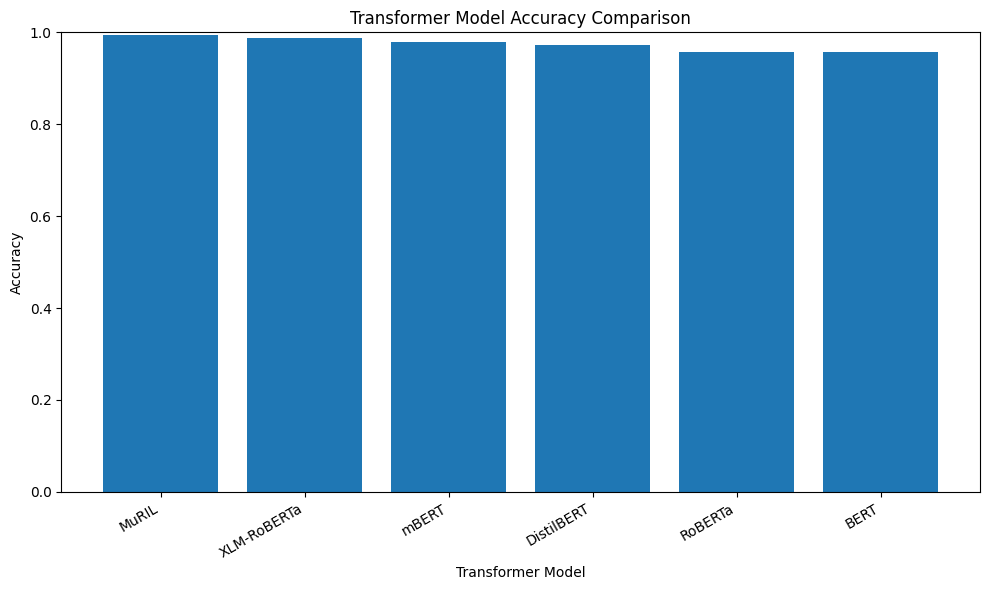

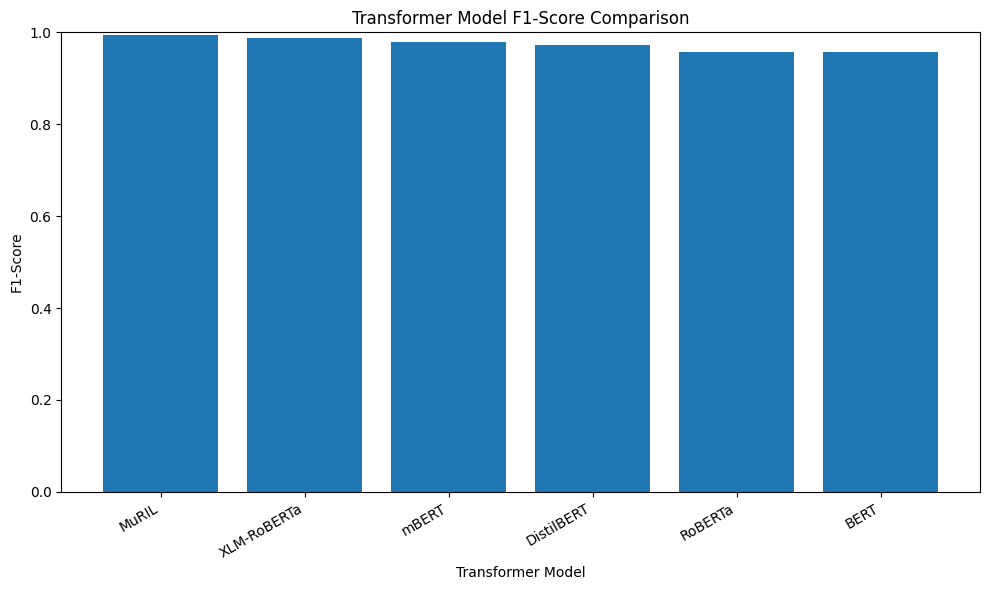

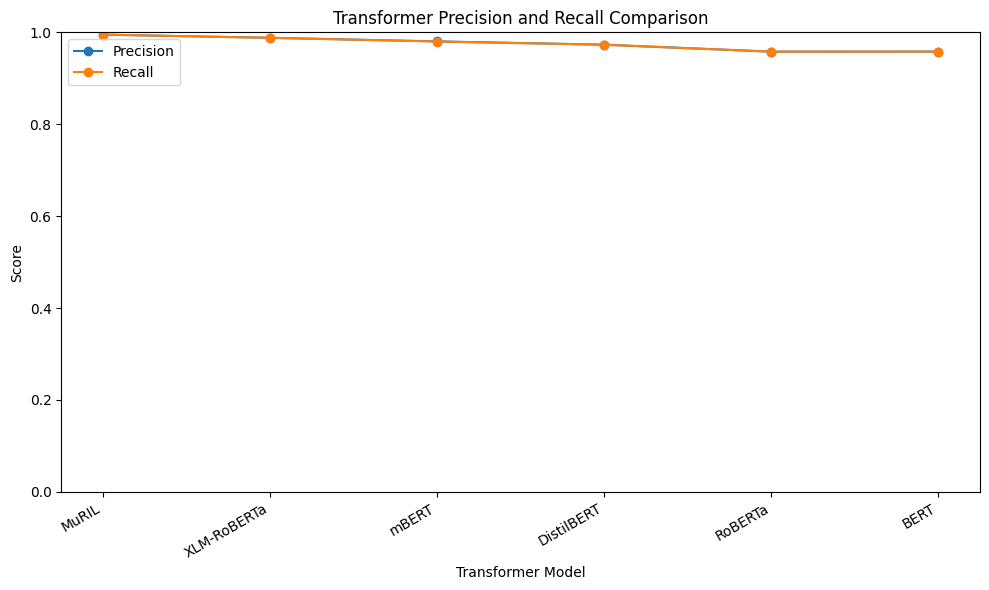


===== FILES CREATED =====
transformer_precision_recall_comparison.png
transformer_accuracy_comparison.png
transformer_comparison.csv
transformer_f1_comparison.png


In [ ]:
# Step 63: Save Transformer Results and Generate Graphs

import os
import matplotlib.pyplot as plt

# Create output folder
os.makedirs("./transformer_results", exist_ok=True)

# --------------------------------------------------
# 1. Save Transformer results as CSV
# --------------------------------------------------

transformer_results.to_csv(
    "./transformer_results/transformer_comparison.csv",
    index=False
)

print("Transformer comparison CSV saved!")


# --------------------------------------------------
# 2. Accuracy Comparison
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    transformer_results["Model"],
    transformer_results["Accuracy"]
)

plt.xlabel("Transformer Model")
plt.ylabel("Accuracy")
plt.title("Transformer Model Accuracy Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "./transformer_results/transformer_accuracy_comparison.png",
    dpi=300
)

plt.show()


# --------------------------------------------------
# 3. F1-Score Comparison
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    transformer_results["Model"],
    transformer_results["F1-Score"]
)

plt.xlabel("Transformer Model")
plt.ylabel("F1-Score")
plt.title("Transformer Model F1-Score Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "./transformer_results/transformer_f1_comparison.png",
    dpi=300
)

plt.show()


# --------------------------------------------------
# 4. Precision / Recall Comparison
# --------------------------------------------------

plt.figure(figsize=(10, 6))

x = range(len(transformer_results))

plt.plot(
    x,
    transformer_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    x,
    transformer_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xticks(
    x,
    transformer_results["Model"],
    rotation=30,
    ha="right"
)

plt.xlabel("Transformer Model")
plt.ylabel("Score")
plt.title("Transformer Precision and Recall Comparison")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "./transformer_results/transformer_precision_recall_comparison.png",
    dpi=300
)

plt.show()


print("\n===== FILES CREATED =====")

for file in os.listdir("./transformer_results"):
    print(file)

In [ ]:
# Step 64: Collect All Sentiment Transformer Files

import os
import shutil

BASE_DIR = "./sentiment_transformer_results"

os.makedirs(BASE_DIR, exist_ok=True)

# --------------------------------------------------
# 1. Copy Transformer comparison files
# --------------------------------------------------

if os.path.exists("./transformer_results"):
    shutil.copytree(
        "./transformer_results",
        os.path.join(BASE_DIR, "comparison"),
        dirs_exist_ok=True
    )

# --------------------------------------------------
# 2. Copy all trained Transformer models
# --------------------------------------------------

model_paths = {
    "BERT": "./bert_sentiment_model",
    "mBERT": "./mbert_sentiment_model",
    "RoBERTa": "./roberta_sentiment_model",
    "XLM-RoBERTa": "./xlmr_sentiment_model",
    "MuRIL": "./muril_sentiment_model",
    "DistilBERT": "./distilbert_sentiment_model"
}

for model_name, model_path in model_paths.items():

    if os.path.exists(model_path):

        destination = os.path.join(
            BASE_DIR,
            "models",
            model_name
        )

        shutil.copytree(
            model_path,
            destination,
            dirs_exist_ok=True
        )

        print(f"✅ {model_name} copied")

    else:
        print(f"⚠️ {model_name} folder not found: {model_path}")


# --------------------------------------------------
# 3. Display collected files
# --------------------------------------------------

print("\n===== SENTIMENT TRANSFORMER FILES =====")

for root, dirs, files_list in os.walk(BASE_DIR):

    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file_name in files_list:
        print(f"{indent}    {file_name}")

✅ BERT copied
✅ mBERT copied
✅ RoBERTa copied
✅ XLM-RoBERTa copied
✅ MuRIL copied
✅ DistilBERT copied

===== SENTIMENT TRANSFORMER FILES =====
sentiment_transformer_results/
    models/
        DistilBERT/
            model.safetensors
            training_args.bin
            config.json
            tokenizer_config.json
            tokenizer.json
        XLM-RoBERTa/
            model.safetensors
            training_args.bin
            config.json
            tokenizer_config.json
            tokenizer.json
        BERT/
            model.safetensors
            training_args.bin
            config.json
            tokenizer_config.json
            tokenizer.json
        RoBERTa/
            model.safetensors
            training_args.bin
            config.json
            tokenizer_config.json
            tokenizer.json
        mBERT/
            model.safetensors
            training_args.bin
            config.json
            tokenizer_config.json
            tokenizer.json
  

In [ ]:
# Step 65: Create Complete Sentiment Transformer ZIP

import shutil
import os

zip_path = shutil.make_archive(
    "./sentiment_transformer_complete",
    "zip",
    "./sentiment_transformer_results"
)

print("===== ZIP CREATED =====")
print("File:", zip_path)
print("Size:", round(os.path.getsize(zip_path) / (1024**2), 2), "MB")

===== ZIP CREATED =====
File: /content/sentiment_transformer_complete.zip
Size: 3462.63 MB


In [ ]:
from google.colab import files

files.download(
    "./sentiment_transformer_complete.zip"
)